# Normal Distribution <hr style="border:2.5px solid rgb(242, 218, 161)"></hr>

<b>John Clark Dojoles</b>
<br>Computer Engineer

In [54]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv(r"dataset\transformer-voltage-10-sample.csv",
                 delimiter=",",
                 index_col=["Sample"])
df

,Voltage
Sample,
1,118.3
2,119.2
3,119.7
4,119.5
5,120.0
6,120.1
7,120.2
8,120.8
9,121.5


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  10 non-null     float64
dtypes: float64(1)
memory usage: 212.0 bytes


In [57]:
df.describe()

,Voltage
count,10.000000
mean,120.110000
std,1.050344
min,118.300000
25%,119.550000
50%,120.050000
75%,120.650000
max,121.800000


In [58]:
alpha = 0.05
n = df['Voltage'].count()

t_critical = stats.t.ppf(1-alpha/2,n-1)
t_critical

np.float64(2.262157162798205)

In [59]:
n = df['Voltage'].count()
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

ci_lower, ci_upper = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std/np.sqrt(n)
)

print(f"ci: [{ci_lower:.2f} to {ci_upper:.2f}]")

ci: [119.36 to 120.86]


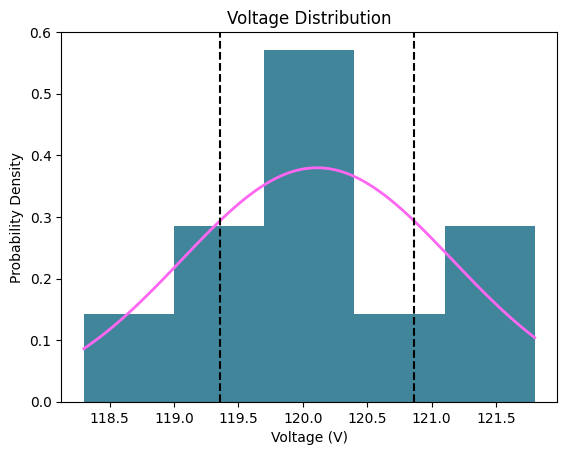

In [60]:
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

x = np.linspace(x_min,x_max,100)
p = stats.norm.pdf(x,mean,std)
plt.plot(x,p,
         linewidth=2,
         color='#FF66F1')


plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color='#126782')

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

# confidence interval
plt.axvline(x=ci_lower,
            color='black',
            linestyle='--')
plt.axvline(x=ci_upper,
            color='black',
            linestyle='--')

plt.show()

# Shoe Inventory

In [61]:
df = pd.read_csv(r"dataset\shoe-inventory.csv",
                 delimiter=",")
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10


In [62]:
df.shape

(17, 13)

In [63]:
mean_size_6 = df.iloc[0:13].mean()  # exclude column index = 13
mean_size_6

Size     9.000000
Jan      8.230769
Feb      9.615385
Mar      9.923077
Apr      7.615385
May     11.615385
Jun     11.000000
Jul     12.153846
Aug     13.615385
Sep     10.923077
Oct     13.615385
Nov      9.230769
Dec      7.153846
dtype: float64

In [64]:
std_size_6 = df.iloc[0:13].std()
std_size_6

Size     1.947220
Jan      6.482719
Feb      9.233440
Mar      9.638997
Apr      7.643499
May      9.087890
Jun     11.525334
Jul      9.099873
Aug     13.251028
Sep     10.086803
Oct     12.971369
Nov     10.158361
Dec      7.956613
dtype: float64

In [65]:
n = df.shape[1]  # columns 13 in (17,13)

lower_6, upper_6 = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean_size_6,
    scale = std_size_6/np.sqrt(n)
)

print(lower_6)
print(upper_6)

[7.82330659 4.31330156 4.0356728  4.09828954 2.9964644  6.12362769
 4.03531012 6.65484781 5.60786852 4.82768302 5.77686486 3.09213283
 2.34571297]
[10.17669341 12.1482369  15.19509643 15.7478643  12.23430483 17.10714154
 17.96468988 17.65284449 21.62290071 17.01847082 21.45390437 15.36940563
 11.96197934]


In [73]:
mean = df.iloc[:,0:13].mean(axis=1)  # all 16 sizes
std = df.iloc[:,0:13].std(axis=1)

df['ci_lower'], df['ci_upper'] = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std/np.sqrt(n)
)

In [67]:
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,ci_lower,ci_upper
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0,2.000764,4.306928
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1,0.662329,3.414594
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0,0.566963,3.586883
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1,1.929998,5.070002
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6,4.432147,8.029392
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6,8.296277,12.857570
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10,13.800634,22.353212
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26,22.709756,34.751783
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20,17.970070,25.568392
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10,14.051275,20.025648


In [68]:
df['ci_lower'] = df['ci_lower'].fillna(0)
df['ci_upper'] = df['ci_upper'].fillna(0)

In [69]:
df['ci_lower'] = df['ci_lower'].astype(int).round(0)
df['ci_upper'] = df['ci_upper'].astype(int).round(0)

In [70]:
df[['Size','ci_upper']]

,Size,ci_upper
0,6.0,4
1,6.5,3
2,7.0,3
3,7.5,5
4,8.0,8
5,8.5,12
6,9.0,22
7,9.5,34
8,10.0,25
9,10.5,20
